#Task 1 — Data Loading & Exploration


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [ ]:
# - Load Dataset

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [ ]:
#- Shape and Info

print("Shape:", df.shape)

df.info()

Shape: (1470, 35)
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 no

In [ ]:
# - Attrition Counts

print(df["Attrition"].value_counts())

attrition_rate = (
    df["Attrition"].value_counts(normalize=True)["Yes"] * 100
)

print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition Rate: 16.12%


In [ ]:
#- Numeric vs Categorical

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

print("Numeric Columns:", len(num_cols))
print("Categorical Columns:", len(cat_cols))

Numeric Columns: 26
Categorical Columns: 9


Task 2 — Data Cleaning & Preprocessing


In [7]:
#Check Missing Values

df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [8]:
#Drop Irrelevant Columns

drop_cols = [
    "EmployeeNumber",
    "Over18",
    "StandardHours",
    "EmployeeCount"
]

df = df.drop(columns=drop_cols)

print(df.shape)

(1470, 31)


In [9]:
#Convert Target Variable

df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

df["Attrition"].head()


0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64

In [11]:
#One-Hot Encoding

df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

print(df_encoded.shape)

(1470, 45)


In [12]:
#Features and Target

X = df_encoded.drop("Attrition", axis=1)
y = df_encoded["Attrition"]

print(X.shape)
print(y.shape)

(1470, 44)
(1470,)


In [13]:
#Scale Features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(1470, 44)


 Task 2 - Data Cleaning & Preprocessing

## Observations

- No missing values were found in the dataset.
- Irrelevant columns such as EmployeeNumber, Over18, StandardHours, and EmployeeCount were removed.
- The target variable Attrition was converted from Yes/No to 1/0.
- Categorical features were transformed using One-Hot Encoding.
- Numeric features were standardized using StandardScaler to improve model performance.

In [14]:
df_encoded.shape

(1470, 45)

Task 3 – Exploratory Data Analysis (EDA)

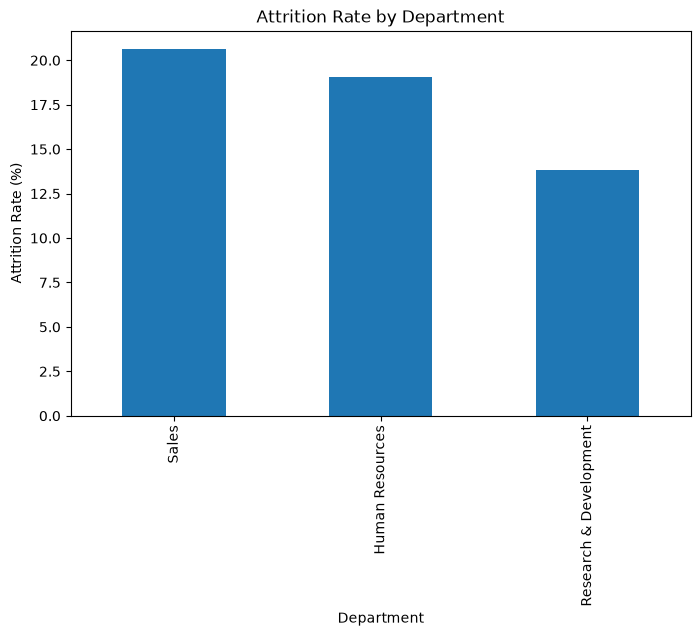

In [23]:
#Chart 1: Attrition Rate by Department

department_attrition[1].sort_values(
    ascending=False
).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Department")

plt.savefig(
    "charts/attrition_department.png",
    bbox_inches="tight"
)

plt.show()

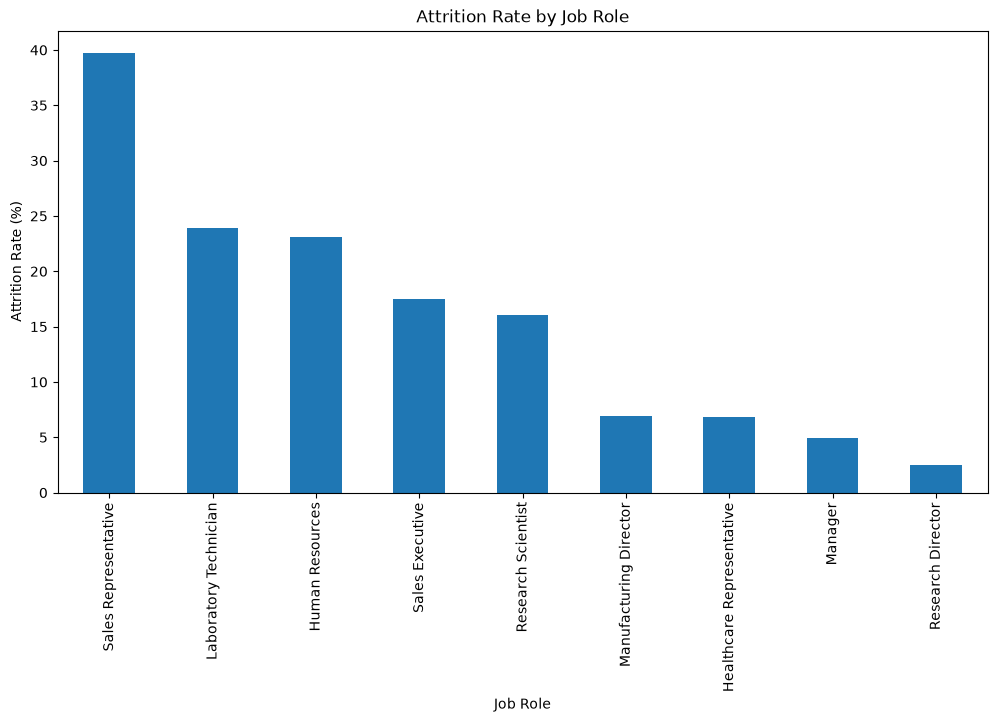

In [24]:
#Chart 2: Attrition Rate by Job Role

jobrole_attrition[1].sort_values(
    ascending=False
).plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Attrition Rate by Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Job Role")

plt.savefig(
    "charts/attrition_jobrole.png",
    bbox_inches="tight"
)

plt.show()

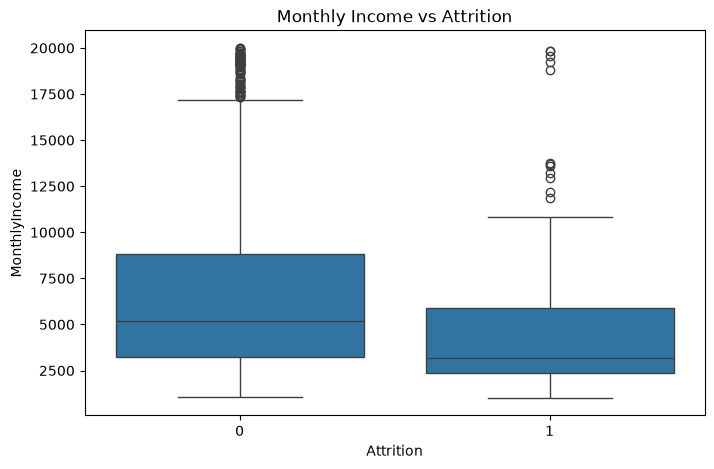

In [25]:
#Chart 3: Monthly Income vs Attrition

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df
)

plt.title("Monthly Income vs Attrition")

plt.savefig(
    "charts/income_vs_attrition.png",
    bbox_inches="tight"
)

plt.show()

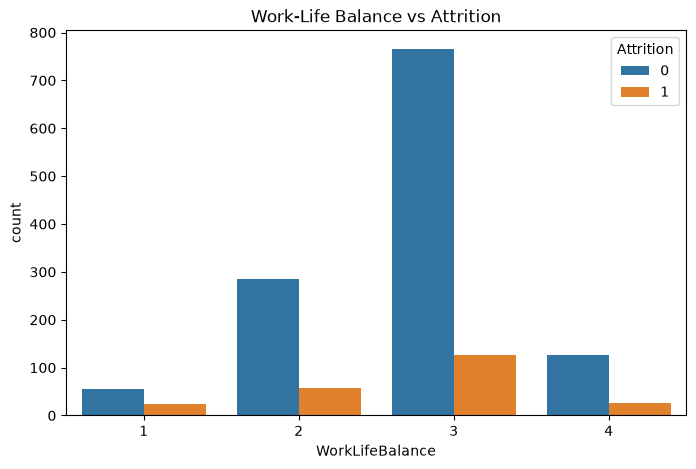

In [26]:
#Chart 4: Work-Life Balance vs Attrition

plt.figure(figsize=(8,5))

sns.countplot(
    x="WorkLifeBalance",
    hue="Attrition",
    data=df
)

plt.title("Work-Life Balance vs Attrition")

plt.savefig(
    "charts/worklife_vs_attrition.png",
    bbox_inches="tight"
)

plt.show()

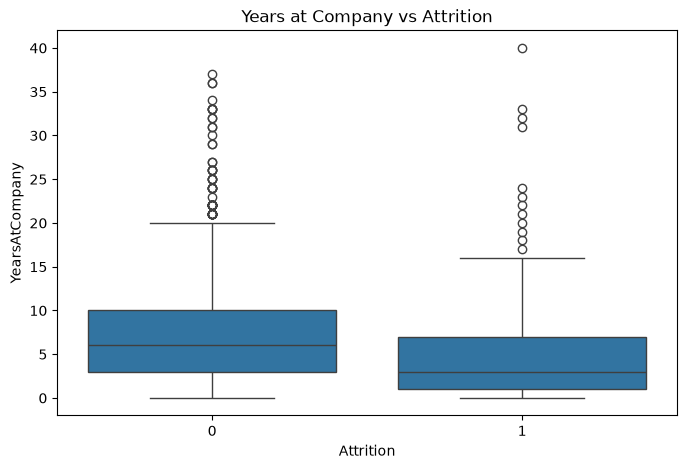

In [27]:
#Chart 5: Years at Company vs Attrition

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="YearsAtCompany",
    data=df
)

plt.title("Years at Company vs Attrition")

plt.savefig(
    "charts/years_company_attrition.png",
    bbox_inches="tight"
)

plt.show()

In [28]:
import os

os.makedirs("charts", exist_ok=True)

print("Charts folder created successfully!")

Charts folder created successfully!


## Business Insights

1. Employees in the Sales department showed higher attrition compared to other departments, indicating that customer-facing roles may experience greater work pressure and turnover.

2. Certain job roles such as Sales Representative and Laboratory Technician exhibited noticeably higher attrition rates, suggesting that these positions require targeted retention strategies.

3. Employees who left the company generally had lower monthly incomes than employees who stayed, indicating that compensation may contribute to employee turnover.

4. Employees with lower Work-Life Balance ratings were more likely to leave the organization, highlighting the importance of employee well-being and workplace flexibility.

5. Attrition was highest among employees with fewer years at the company, suggesting that employees are most likely to leave during the early stages of their careers with the organization.

Task 4 — Model Building & Comparison

In [29]:
#Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1176, 44)
(294, 44)


In [31]:
#Logistic Regression

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

lr.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [32]:
#Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [33]:
#Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

print("Gradient Boosting trained successfully!")

Gradient Boosting trained successfully!


#Task 5 — Model Evaluation

In [34]:
#Import Metrics

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [35]:
#Evaluation Function

def evaluate_model(model):

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    return {
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

In [36]:
#Comparison Table

comparison = pd.DataFrame({
    "Logistic Regression": evaluate_model(lr),
    "Random Forest": evaluate_model(rf),
    "Gradient Boosting": evaluate_model(gb)
}).T

comparison

,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.341176,0.617021,0.439394,0.798605
Random Forest,0.437500,0.297872,0.354430,0.778577
Gradient Boosting,0.588235,0.212766,0.312500,0.794384


In [37]:
#Best Model

comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.341176,0.617021,0.439394,0.798605
Gradient Boosting,0.588235,0.212766,0.312500,0.794384
Random Forest,0.437500,0.297872,0.354430,0.778577


## Best Model

Logistic Regression performed best with a ROC-AUC score of 0.7986 and the highest recall score of 0.6170. Since employee attrition prediction focuses on identifying employees who may leave, a higher recall is particularly important because it reduces the number of employees at risk who are missed by the model.

#Task 6 — Visualization

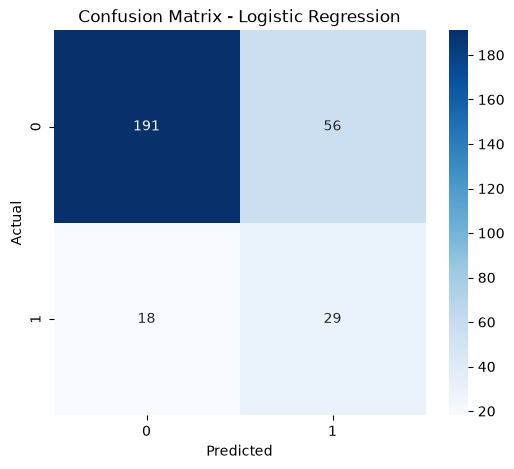

In [38]:
#Logistic Regression confusion matrix

from sklearn.metrics import confusion_matrix

y_pred = lr.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "charts/confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

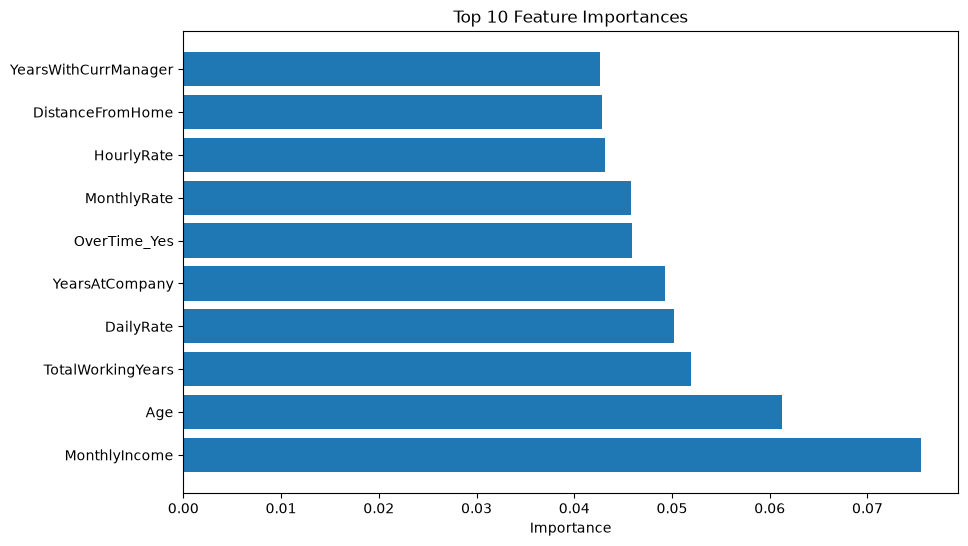

In [40]:
#Top 10 Feature Importances

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

top10 = importance.head(10)

top10

plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")

plt.savefig(
    "charts/feature_importance.png",
    bbox_inches="tight"
)

plt.show()

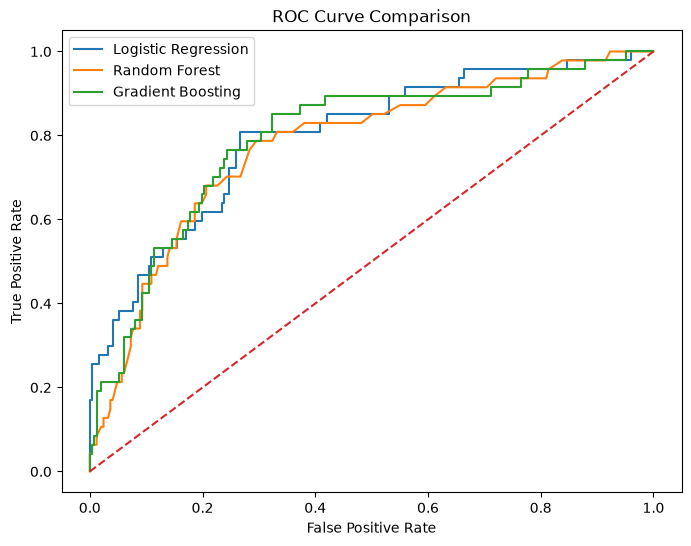

In [41]:
#(Bonus): ROC Curve Comparison

from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

for model, name in [
    (lr,"Logistic Regression"),
    (rf,"Random Forest"),
    (gb,"Gradient Boosting")
]:

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.savefig(
    "charts/roc_curve.png",
    bbox_inches="tight"
)

plt.show()

# Task 7 – HR Insights & Business Recommendations

The analysis showed that employee turnover is influenced by several factors, including salary, work-life balance, and years of service. Employees in certain departments and job roles were more likely to leave than others. While compensation is important, workplace experience and employee satisfaction also play a significant role in retention. HR should focus on supporting newer employees, improving work-life balance, and monitoring departments with higher turnover rates. One limitation of this analysis is that it cannot capture personal reasons for leaving, such as family situations or opportunities outside the company.
